In [4]:
import cv2
import pandas 
import numpy as np
import matplotlib.pyplot as plt
import os


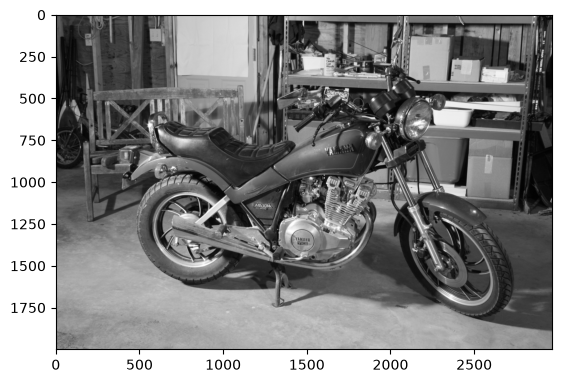

In [5]:
LeftImage1 = cv2.imread('dataset/im0/im0.png',0)
LeftImage1 = np.asarray(LeftImage1)
plt.imshow(LeftImage1,cmap = 'gray')

# cv2.imshow(RightImage1)

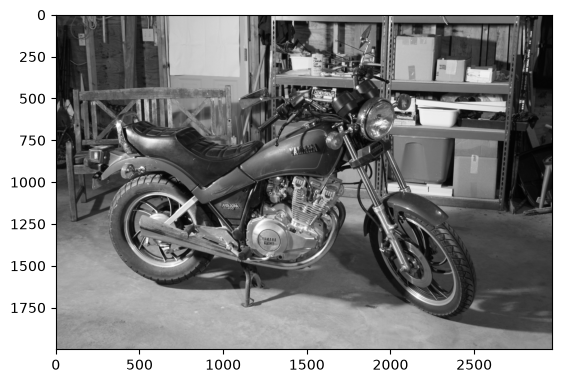

In [6]:
RightImage1 = cv2.imread('dataset/im0/im1.png',0)

RightImage1 = np.asarray(RightImage1)
plt.imshow(RightImage1,cmap = 'gray')

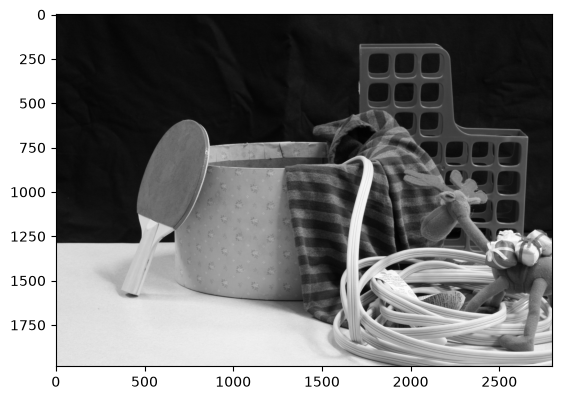

In [7]:
LeftImage2 = cv2.imread('dataset/img1/im0.png',0)
LeftImage2 = np.asarray(LeftImage2)
plt.imshow(LeftImage2,cmap = 'gray')

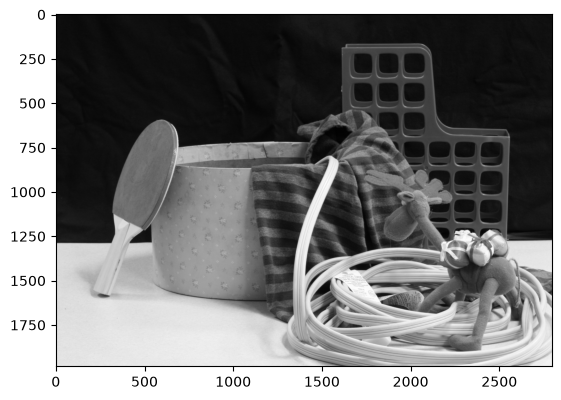

In [8]:
RightImage2 = cv2.imread('dataset/img1/im1.png',0)

RightImage2 = np.asarray(RightImage2)
plt.imshow(RightImage2,cmap = 'gray')

In [9]:
def disp(imgL,imgR,disparity):
    stereo  = cv2.StereoBM_create(numDisparities = disparity , blockSize = 15)
    disparity = stereo.compute(imgL,imgR)
    disparity = cv2.normalize(disparity,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
    colorMap = cv2.applyColorMap(disparity, cv2.COLORMAP_JET)
    plt.imshow(disparity,'gray')
    plt.show()
    return disparity , colorMap

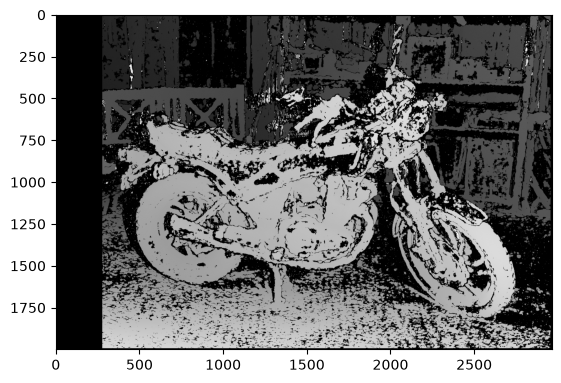

In [17]:
image1,ColorMap1 = disp(LeftImage1,RightImage1,272)

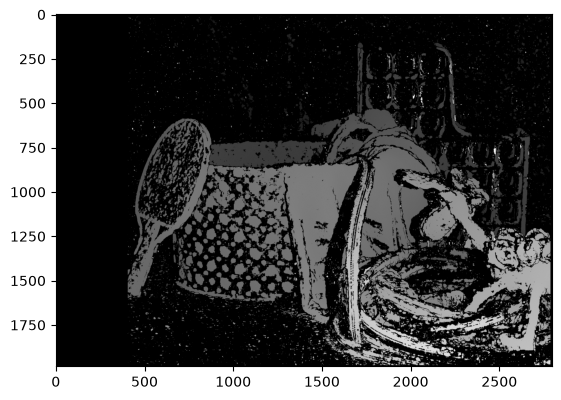

In [18]:
image1,ColorMap2 = disp(LeftImage2,RightImage2,400)

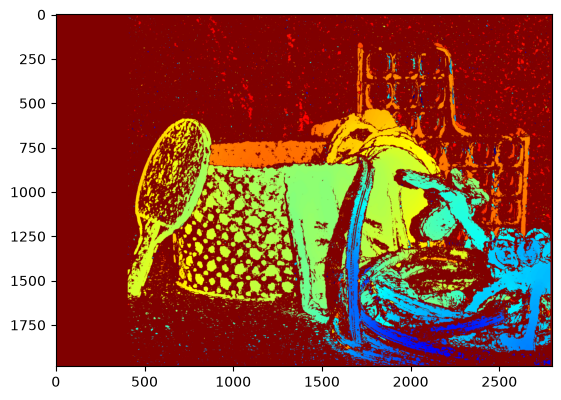

In [19]:
plt.imshow(ColorMap2)
plt.show()

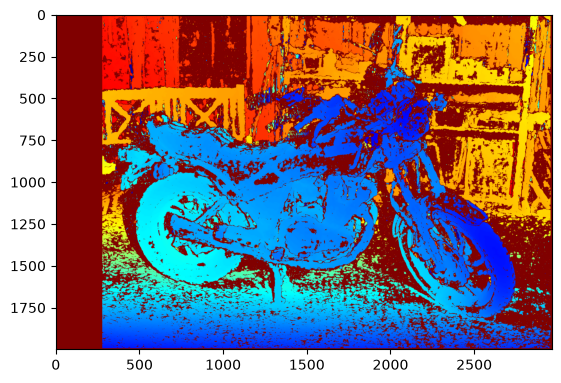

In [20]:
plt.imshow(ColorMap1)
plt.show()

In [21]:
cv2.imwrite('dataset/colormap1.png',ColorMap1)
cv2.imwrite('dataset/colormap2.png',ColorMap2)

True

In [22]:

cam01=np.array([[3979.911,     0,      1244.772],
                           [0,        3979.911, 1019.507],
                           [0,          0,        1      ]]) 
cam11=np.array([[3979.911,     0,      1369.115],
                                [0,        3979.911, 1019.507],
                                [0,          0,        1      ]])
doffs1=124.343 
baseline1=193.001
width1=2964
height1=2000
ndisp1=270 


In [23]:
cam02 = np.array([[6338.47, 0, 1035.675],
                                  [0, 6338.47, 960.073],
                                  [0, 0, 1]])
cam12 = np.array([[6338.47, 0, 1515.164],
                                  [0, 6338.47, 960.073],
                                  [0, 0, 1]])
doffs2=479.489 # disparity offset, add this when getting the 3d coordinate as this 2 specific images have different principle points
baseline2=171.548
width2=2796
height2=1984
ndisp2=390  # number of  disparities


In [31]:
def depth_calculation(fx,baseline,disparity,doffs):
    return fx*baseline / (disparity+doffs)

In [ ]:

depth2 = depth_calculation(6338.47,baseline2 , 400,doffs2)

In [ ]:
x,y = 1000,500
Valuedisp = image1[y,x]/16.0
depth1 = depth_calculation(3979.911,baseline1,Valuedisp,doffs1)


Depth at (1000,500): 6177.48 mm


In [ ]:

!git add .
!git commit -m "idk"